**lag 추가 binary 삭제**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

In [19]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/test.csv')

In [20]:
# ── timeslot 추가 ─────────────────────────────────────────
# 시나리오 내 슬롯 순서 (0~24)
# EDA에서 슬롯 0=11.3분 → 슬롯 24=21.9분으로 누적 증가 확인
train['timeslot'] = train.groupby('scenario_id').cumcount()
test['timeslot']  = test.groupby('scenario_id').cumcount()

In [21]:
drop_cols = ['ID', 'scenario_id', 'avg_delay_minutes_next_30m', 'layout_id']
target = 'avg_delay_minutes_next_30m'

In [22]:
# ── Lag 피처 ──────────────────────────────────────────────
train = train.sort_values(['scenario_id', 'timeslot']).reset_index(drop=True)
test  = test.sort_values(['scenario_id', 'timeslot']).reset_index(drop=True)

lag_cols = [
    'battery_mean',
    'low_battery_ratio',
    'order_inflow_15m',
    'robot_utilization',
    'robot_charging',
    'congestion_score',
]

for col in lag_cols:
    if col not in train.columns:
        continue
    # lag1: 직전 슬롯 값
    train[f'{col}_lag1'] = train.groupby('scenario_id')[col].shift(1)
    test[f'{col}_lag1']  = test.groupby('scenario_id')[col].shift(1)

    # diff1: 직전 슬롯 대비 변화량 (소모 속도)
    # battery_diff1이 음수 = 배터리 소모 중
    # order_diff1이 양수  = 주문 증가 중
    train[f'{col}_diff1'] = train[col] - train[f'{col}_lag1']
    test[f'{col}_diff1']  = test[col]  - test[f'{col}_lag1']

print(f'추가된 피처 수: {len(lag_cols) * 2}개')  # lag1 + diff1
print(f'전체 피처 수: {len(train.drop(columns=["ID","scenario_id",target,"layout_id"]).columns)}개')


추가된 피처 수: 12개
전체 피처 수: 103개


In [23]:
X      = train.drop(columns=drop_cols).fillna(-999)
y      = train[target]
X_test = test.drop(columns=['ID', 'scenario_id', 'layout_id']).fillna(-999)
groups = train['scenario_id']

In [24]:
print(f'피처 수: {X.shape[1]}')
print(f'timeslot 포함 확인: {"timeslot" in X.columns}')
print(f'결측 수: {X.isnull().sum().sum()}')  # 0이어야 함


피처 수: 103
timeslot 포함 확인: True
결측 수: 0


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.254058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22388
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 103
[LightGBM] [Info] Start training from score 9.016370
[200]	valid_0's l1: 9.58937
Fold 1 | MAE: 9.5878 | best iter: 264
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.384709 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22384
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 103
[LightGBM] [Info] Start training from score 9.021746
Fold 2 | MAE: 9.3049 | best iter: 97
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.257675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22385
[LightGBM]

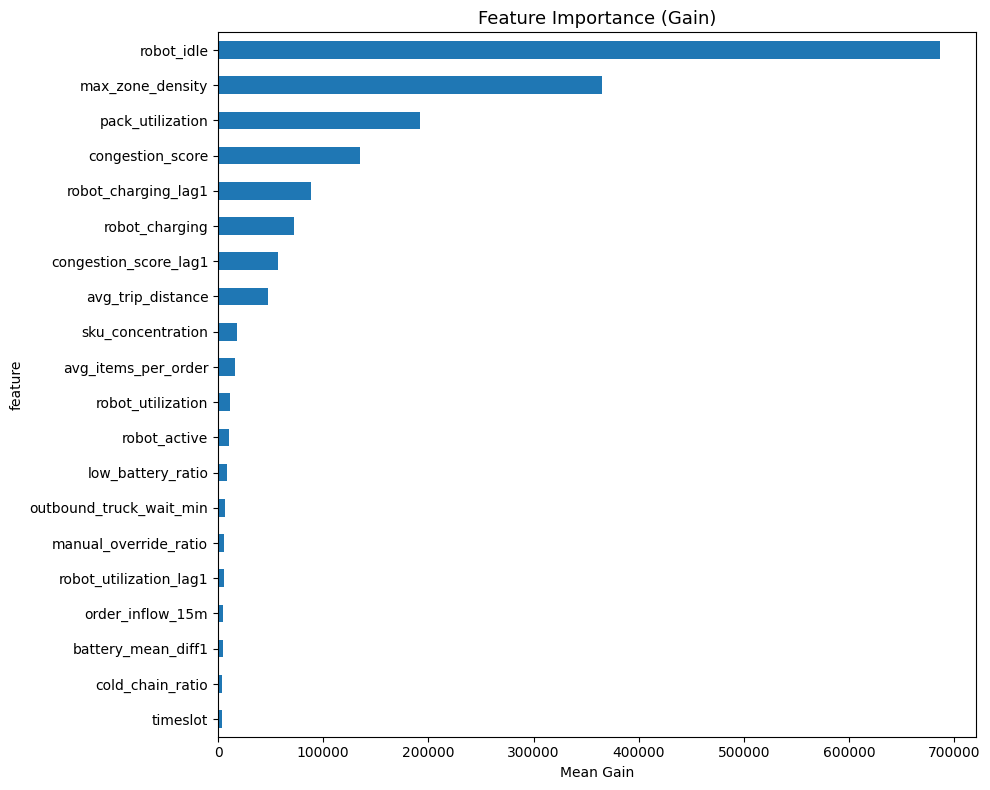

In [25]:
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

# ── 5-Fold GroupKFold ─────────────────────────────────────
gkf = GroupKFold(n_splits=5)
oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(X_test))
mae_scores = []
feature_importances = pd.DataFrame()

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        objective='mae',
        metric='mae',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

    oof_pred[val_idx] = model.predict(X_val)
    test_pred += model.predict(X_test) / 5

    fold_mae = mean_absolute_error(y_val, oof_pred[val_idx])
    mae_scores.append(fold_mae)

    # gain 중요도로 기록
    imp = pd.DataFrame({
        'feature': X.columns,
        'gain': model.booster_.feature_importance(importance_type='gain'),
        'split': model.booster_.feature_importance(importance_type='split'),
        'fold': fold + 1
    })
    feature_importances = pd.concat([feature_importances, imp], axis=0)

    print(f'Fold {fold+1} | MAE: {fold_mae:.4f} | best iter: {model.best_iteration_}')

oof_mae = mean_absolute_error(y, oof_pred)
print(f'\n✅ 각 Fold MAE: {[round(m, 4) for m in mae_scores]}')
print(f'✅ 평균 MAE:    {np.mean(mae_scores):.4f}')
print(f'✅ OOF MAE:     {oof_mae:.4f}')

# ── 피처 중요도 (gain 기준) ───────────────────────────────
imp_mean = (
    feature_importances
    .groupby('feature')[['gain', 'split']]
    .mean()
    .sort_values('gain', ascending=False)
    .head(20)
)

print('\n✅ 상위 20개 피처 중요도 (gain 기준)')
print(imp_mean.round(1))

fig, ax = plt.subplots(figsize=(10, 8))
imp_mean['gain'].sort_values().plot.barh(ax=ax)
ax.set_title('Feature Importance (Gain)', fontsize=13)
ax.set_xlabel('Mean Gain')
plt.tight_layout()
plt.show()

# ── 제출용 예측값 후처리 ──────────────────────────────────
test_pred = np.clip(test_pred, 0, None)

In [26]:
submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/sample_submission.csv')
submission['avg_delay_minutes_next_30m'] = test_pred
submission.to_csv('submission_v4_lag.csv', index=False)
print("\nsubmission_v4_lag.csv 저장")



submission_v4_lag.csv 저장
